# Rogue Wave Discovery via Physics-Informed Neural Network

This notebook trains a neural network to discover the soliton (rogue wave) solution of the **1D Duffing ODE**:

$$u'' = A \cdot u - B \cdot u^3$$

The analytic soliton solution is:

$$u(x) = \sqrt{\frac{2A}{B}} \cdot \text{sech}\!\left(\sqrt{B}\, x\right)$$

The network learns both the solution function $u(x)$ **and** the ODE parameters $A$ and $B$ simultaneously — with **no labeled training data**, only physics constraints.

## 0. Imports & Reproducibility

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pylab as pl

# Fix random seeds for reproducibility
np.random.seed(37)
torch.manual_seed(42)

device = torch.device('cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Create the Input Data

Generate $x$ randomly in $[-L,\, +L]$ with $L = 5$, then split into two regions:

- **Inside** — $|x| < L/10$ (near the peak, enforces shape constraints)
- **Outside** — $|x| \geq L/10$ (tail region, enforces decay constraints)

In [4]:
n_data = 10**3
L = 5.0

x_all = np.random.uniform(-L, +L, size=n_data)

# Split: |x| < L/10  vs the rest
mask_in = np.abs(x_all) < (L / 10)
x_in  = x_all[mask_in]
x_out = x_all[~mask_in]

print(f"Total points : {len(x_all)}")
print(f"Inside  (|x| < {L/10}): {len(x_in)}")
print(f"Outside (|x| >= {L/10}): {len(x_out)}")

Total points : 1000
Inside  (|x| < 0.5): 108
Outside (|x| >= 0.5): 892


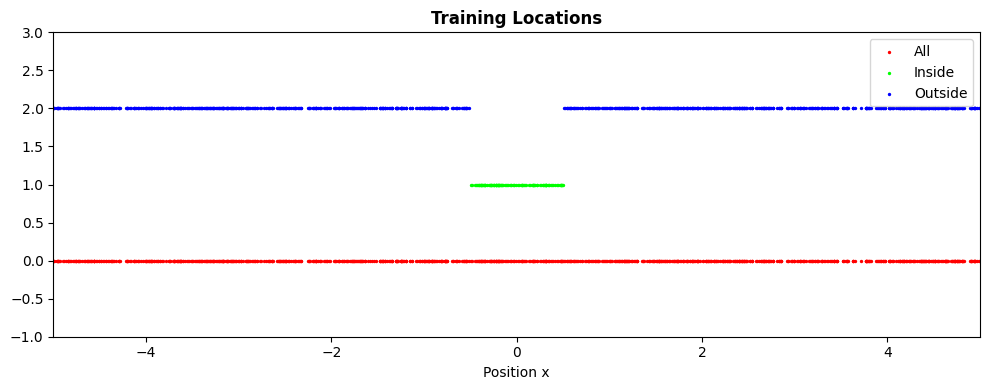

In [5]:
f = pl.figure(figsize=(10, 4))
ax = f.add_subplot(1, 1, 1)

ax.scatter(x_all, 0 * x_all,     s=2, color=(1, 0, 0), label='All')
ax.scatter(x_in,  0 * x_in  + 1, s=2, color=(0, 1, 0), label='Inside')
ax.scatter(x_out, 0 * x_out + 2, s=2, color=(0, 0, 1), label='Outside')

ax.set_title('Training Locations', fontweight='bold')
ax.set_xlabel('Position x')
ax.axis([-L, +L, -1, +3])
ax.legend()
pl.tight_layout()
pl.show()

Convert the NumPy arrays to PyTorch tensors for use in the network.

In [6]:
x_all_Input = torch.tensor(x_all, dtype=torch.float32).unsqueeze(1)
x_in_Input  = torch.tensor(x_in,  dtype=torch.float32).unsqueeze(1)
x_out_Input = torch.tensor(x_out, dtype=torch.float32).unsqueeze(1)

x_all_Input.shape, x_in_Input.shape, x_out_Input.shape

(torch.Size([1000, 1]), torch.Size([108, 1]), torch.Size([892, 1]))

## 2. Define the Neural Network

A single hidden layer with 32 neurons and Tanh activation.

- **Input**: scalar $x$
- **Output**: scalar $u(x)$

A second hidden layer (`fc2`) is left commented-out for optional depth experiments.

In [7]:
class Network(nn.Module):

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 32)
        # self.fc2 = nn.Linear(32, 32)  # optional second hidden layer
        self.fc3 = nn.Linear(32, 1)
        self.activation = nn.Tanh()

    def forward(self, x):
        x = self.activation(self.fc1(x))
        # x = self.activation(self.fc2(x))
        x = self.fc3(x)
        return x


u_NN = Network().to(device)
u_NN

Network(
  (fc1): Linear(in_features=1, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (activation): Tanh()
)

## 3. Learnable ODE Parameters

$A$ and $B$ are treated as trainable scalars, optimized jointly with the network weights.
Positivity is enforced via `softplus`: $A = \text{softplus}(A_{\text{raw}}) + \epsilon$.

In [8]:
# Raw parameters (unconstrained); positivity enforced via softplus
A_raw = nn.Parameter(torch.tensor(1.0))
B_raw = nn.Parameter(torch.tensor(1.0))

def A_B():
    A = F.softplus(A_raw) + 1e-6
    B = F.softplus(B_raw) + 1e-6
    return A, B

A_init, B_init = A_B()
print(f"Initial A = {A_init.item():.4f},  B = {B_init.item():.4f}")

Initial A = 1.3133,  B = 1.3133


## 4. Physics Residuals (Loss Terms)

The loss is a weighted sum of five physics-based residuals:

| Term | Constraint |
|------|------------|
| L1   | $u(0) = u_{\text{peak}}$ — fix center peak height |
| L2   | $u'(0) = 0$ — flat peak (via autograd) |
| L3   | $u(\pm L/10) = u_{\text{peak}}/3$ — fix width via edge values |
| L4   | $|u(x)| \leq u_{\text{peak}}/3$ for $|x| > L/10$ — tail decay |
| L5   | $u'' - (A u - B u^3) = 0$ — ODE residual on all points |

Gradients are computed with `create_graph=True` to allow second-order differentiation.

In [9]:
def gradients(y, x):
    """Compute dy/dx via autograd, keeping the graph for higher-order derivatives."""
    return torch.autograd.grad(
        y, x, grad_outputs=torch.ones_like(y),
        retain_graph=True, create_graph=True
    )[0]


u_peak = 1.0


def center_peak_residual():
    """L1: u(0) = u_peak"""
    x0 = torch.tensor([[0.0]], dtype=torch.float32)
    return u_NN(x0) - u_peak


def flat_peak_residual():
    """L2: u'(0) = 0"""
    x0 = torch.tensor([[0.0]], dtype=torch.float32, requires_grad=True)
    return gradients(u_NN(x0), x0)


def edge_peak_residual():
    """L3: u(±L/10) = u_peak / 3"""
    xe = torch.tensor([[-L / 10], [+L / 10]], dtype=torch.float32)
    return u_NN(xe) - u_peak / 3


def outside_bound_residual(xo):
    """L4: penalise |u(x)| > u_peak/3 in the tail region."""
    return F.relu(torch.abs(u_NN(xo)) - u_peak / 3)


def ode_residual(x):
    """L5: u'' - (A*u - B*u^3) = 0 everywhere."""
    x = x.detach().requires_grad_(True)
    u = u_NN(x)
    dudx    = gradients(u, x)
    ddudxdx = gradients(dudx, x)
    A, B = A_B()
    return ddudxdx - (A * u - B * u**3)

## 5. Training Setup

- **Optimizer**: Adam, `lr = 1e-4`
- **Epochs**: 500 000 - Changing to 200,000 and doing custom learning rate for A and B
- **Loss weights**: `c1=c2=c3=c4=1`, `c5=10` (ODE term up-weighted)

In [10]:
n_epochs      = 2 * 10**5
#learning_rate = 1e-4
n_rep         = 5 * 10**3   # print every n_rep epochs

c1, c2, c3, c4, c5 = 1, 1, 1, 1, 25

# Optimize network weights AND the ODE parameters together
params    = list(u_NN.parameters()) + [A_raw, B_raw]
optimizer = torch.optim.Adam([
      {'params': u_NN.parameters(), 'lr': 1e-4},
      {'params': [A_raw, B_raw],    'lr': 1e-3},  
  ])
mse       = nn.MSELoss()

# Pre-allocate history arrays
Epoch_List      = np.arange(n_epochs) + 1
Train_Loss_List = np.zeros(n_epochs)
Train_L1_List   = np.zeros(n_epochs)
Train_L2_List   = np.zeros(n_epochs)
Train_L3_List   = np.zeros(n_epochs)
Train_L4_List   = np.zeros(n_epochs)
Train_L5_List   = np.zeros(n_epochs)

print("Training configuration ready.")
print(f"  Epochs        : {n_epochs:,}")
print('u_NN Params lr = 1e-4 | A & B lr = 1e-3')
print(f"  Loss weights  : c1={c1}, c2={c2}, c3={c3}, c4={c4}, c5={c5}")

Training configuration ready.
  Epochs        : 200,000
u_NN Params lr = 1e-4 | A & B lr = 1e-3
  Loss weights  : c1=1, c2=1, c3=1, c4=1, c5=25


## 6. Train the Neural Network

Each epoch computes all five residuals, accumulates the weighted loss, and back-propagates.
Progress is printed every 5 000 epochs.

In [11]:
for ep in range(n_epochs):
    u_NN.train()
    optimizer.zero_grad()

    # L1 — peak height
    r1 = center_peak_residual()
    L1 = mse(r1, torch.zeros_like(r1))

    # L2 — flat peak
    r2 = flat_peak_residual()
    L2 = mse(r2, torch.zeros_like(r2))

    # L3 — edge width
    r3 = edge_peak_residual()
    L3 = mse(r3, torch.zeros_like(r3))

    # L4 — tail bound
    r4 = outside_bound_residual(x_out_Input)
    L4 = mse(r4, torch.zeros_like(r4))

    # L5 — ODE residual
    r5 = ode_residual(x_all_Input)
    L5 = mse(r5, torch.zeros_like(r5))

    loss = c1*L1 + c2*L2 + c3*L3 + c4*L4 + c5*L5
    loss.backward()
    optimizer.step()

    Train_Loss_List[ep] = loss.item()
    Train_L1_List[ep]   = L1.item()
    Train_L2_List[ep]   = L2.item()
    Train_L3_List[ep]   = L3.item()
    Train_L4_List[ep]   = L4.item()
    Train_L5_List[ep]   = L5.item()

    if ep % n_rep == 0:
        print(f"Epoch {ep+1:>7,}  Loss: {Train_Loss_List[ep]:.6e}")

Epoch       1  Loss: 7.807302e+00
Epoch   5,001  Loss: 2.368229e-01
Epoch  10,001  Loss: 1.867368e-01
Epoch  15,001  Loss: 1.061070e-01
Epoch  20,001  Loss: 4.918894e-02
Epoch  25,001  Loss: 1.958235e-02
Epoch  30,001  Loss: 7.305745e-03
Epoch  35,001  Loss: 3.032425e-03
Epoch  40,001  Loss: 1.526344e-03
Epoch  45,001  Loss: 7.123164e-04
Epoch  50,001  Loss: 4.442616e-04
Epoch  55,001  Loss: 2.703611e-04
Epoch  60,001  Loss: 1.361532e-04
Epoch  65,001  Loss: 8.339565e-05
Epoch  70,001  Loss: 6.051924e-05
Epoch  75,001  Loss: 6.031453e-05
Epoch  80,001  Loss: 3.891917e-05
Epoch  85,001  Loss: 8.477585e-05
Epoch  90,001  Loss: 5.363787e-05
Epoch  95,001  Loss: 2.630406e-05
Epoch 100,001  Loss: 2.417539e-05
Epoch 105,001  Loss: 2.398911e-05
Epoch 110,001  Loss: 4.804030e-05
Epoch 115,001  Loss: 4.250708e-05
Epoch 120,001  Loss: 1.787344e-05
Epoch 125,001  Loss: 1.668974e-05
Epoch 130,001  Loss: 1.556291e-05
Epoch 135,001  Loss: 1.780507e-04
Epoch 140,001  Loss: 1.515662e-04
Epoch 145,001 

## 7. Loss Curves

Visualise how the total loss and each individual loss term evolved over training.

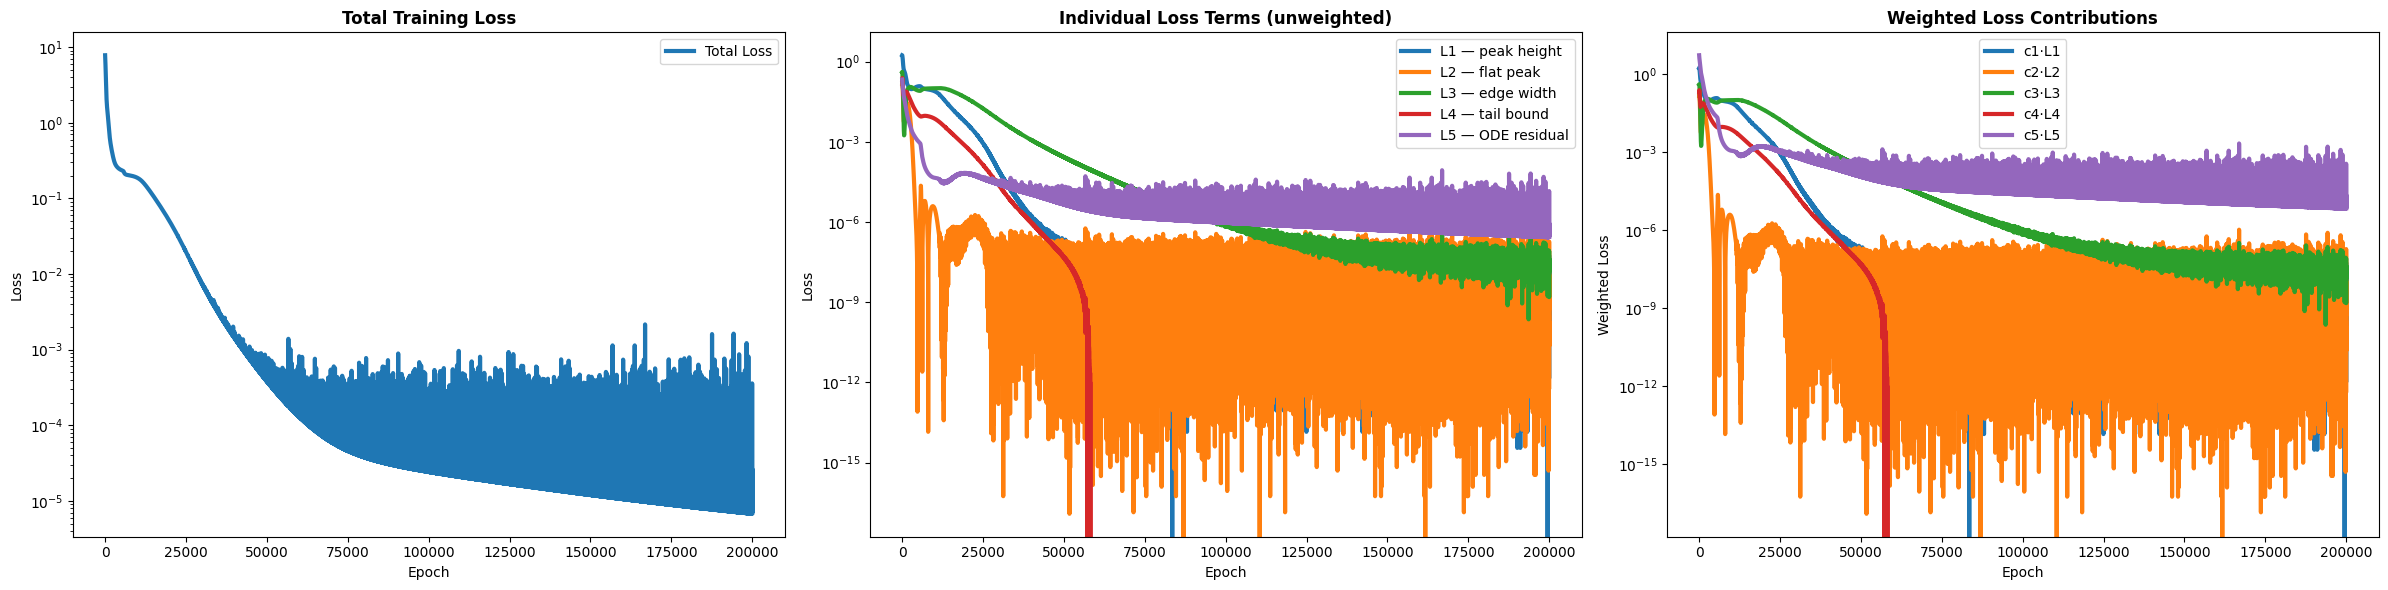

In [12]:
f1, (sf1_1, sf1_2, sf1_3) = pl.subplots(1, 3, figsize=(24, 6))

# Total loss
sf1_1.plot(Epoch_List, Train_Loss_List, lw=3, label='Total Loss')
sf1_1.set_title('Total Training Loss', fontweight='bold')
sf1_1.set_xlabel('Epoch')
sf1_1.set_ylabel('Loss')
sf1_1.set_yscale('log')
sf1_1.legend()

# Individual (unweighted) loss terms
for data, label in [
    (Train_L1_List, 'L1 — peak height'),
    (Train_L2_List, 'L2 — flat peak'),
    (Train_L3_List, 'L3 — edge width'),
    (Train_L4_List, 'L4 — tail bound'),
    (Train_L5_List, 'L5 — ODE residual'),
]:
    sf1_2.plot(Epoch_List, data, lw=3, label=label)
sf1_2.set_title('Individual Loss Terms (unweighted)', fontweight='bold')
sf1_2.set_xlabel('Epoch')
sf1_2.set_ylabel('Loss')
sf1_2.set_yscale('log')
sf1_2.legend()

# Weighted contributions
for data, c, label in [
    (Train_L1_List, c1, 'c1·L1'),
    (Train_L2_List, c2, 'c2·L2'),
    (Train_L3_List, c3, 'c3·L3'),
    (Train_L4_List, c4, 'c4·L4'),
    (Train_L5_List, c5, 'c5·L5'),
]:
    sf1_3.plot(Epoch_List, c * data, lw=3, label=label)
sf1_3.set_title('Weighted Loss Contributions', fontweight='bold')
sf1_3.set_xlabel('Epoch')
sf1_3.set_ylabel('Weighted Loss')
sf1_3.set_yscale('log')
sf1_3.legend()

pl.tight_layout()
pl.show()

## 8. Evaluate the Learned Solution

Compare the network output against:
- **AB Solution** — analytic soliton built from the *learned* $A$ and $B$
- **True Solution** — analytic soliton matched to the boundary constraints

In [13]:
n_val = 10**4
x_test_Input = torch.linspace(-L, +L, steps=n_val).unsqueeze(1)
x_test = x_test_Input.detach().numpy()

u_NN.eval()
with torch.no_grad():
    u_test = u_NN(x_test_Input).numpy()

A_val, B_val = A_B()
A_val = A_val.detach().numpy()
B_val = B_val.detach().numpy()

print(f"Learned  A = {A_val:.4f}")
print(f"Learned  B = {B_val:.4f}")
print(f"Expected A/B ratio ≈ {A_val/B_val:.4f}  (true = 0.5 for unit-peak sech)")

Learned  A = 12.4207
Learned  B = 24.8446
Expected A/B ratio ≈ 0.4999  (true = 0.5 for unit-peak sech)


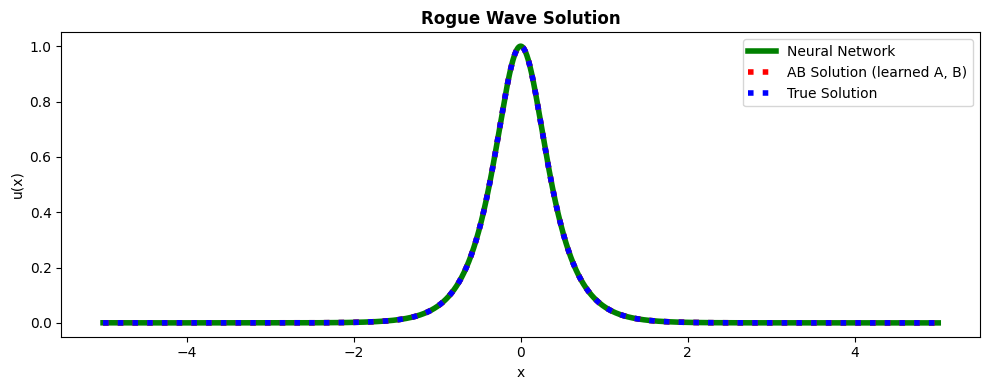

In [14]:
# Analytic soliton using learned A, B
u_withAB  = np.sqrt(2 * A_val / B_val) / np.cosh(np.sqrt(A_val) * x_test)

# True soliton consistent with boundary constraints (u(±L/10) = u_peak/3)
w          = np.arccosh(3) / (L / 10)
u_shouldbe = u_peak / np.cosh(w * x_test)

f2, ax = pl.subplots(figsize=(10, 4))
ax.plot(x_test, u_test,     color='g', lw=4, label='Neural Network')
ax.plot(x_test, u_withAB,   color='r', lw=4, ls=':', label='AB Solution (learned A, B)')
ax.plot(x_test, u_shouldbe, color='b', lw=4, ls=':', label='True Solution')
ax.set_title('Rogue Wave Solution', fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('u(x)')
ax.legend()
pl.tight_layout()
pl.show()

In [15]:
A_val, B_val

(array(12.4207325, dtype=float32), array(24.844637, dtype=float32))